In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: AEP_hourly.csv          
  inflating: COMED_hourly.csv        
  inflating: DAYTON_hourly.csv       
  inflating: DEOK_hourly.csv         
  inflating: DOM_hourly.csv          
  inflating: DUQ_hourly.csv          
  inflating: EKPC_hourly.csv         
  inflating: FE_hourly.csv           
  inflating: NI_hourly.csv           
  inflating: PJME_hourly.csv         
  inflating: PJMW_hourly.csv         
  inflating: PJM_Load_hourly.csv     
  inflating: est_hourly.paruqet      
  inflating: pjm_hourly_est.csv      


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from sklearn.metrics import r2_score
import sklearn.preprocessing
from keras.layers import Dense, Dropout, SimpleRNN, LSTM
from keras.models import Sequential

In [ ]:
df = pd.read_csv("DOM_hourly.csv",index_col = "Datetime",parse_dates=True)
df.head()

,DOM_MW
Datetime,
2005-12-31 01:00:00,9389.0
2005-12-31 02:00:00,9070.0
2005-12-31 03:00:00,9001.0
2005-12-31 04:00:00,9042.0
2005-12-31 05:00:00,9132.0


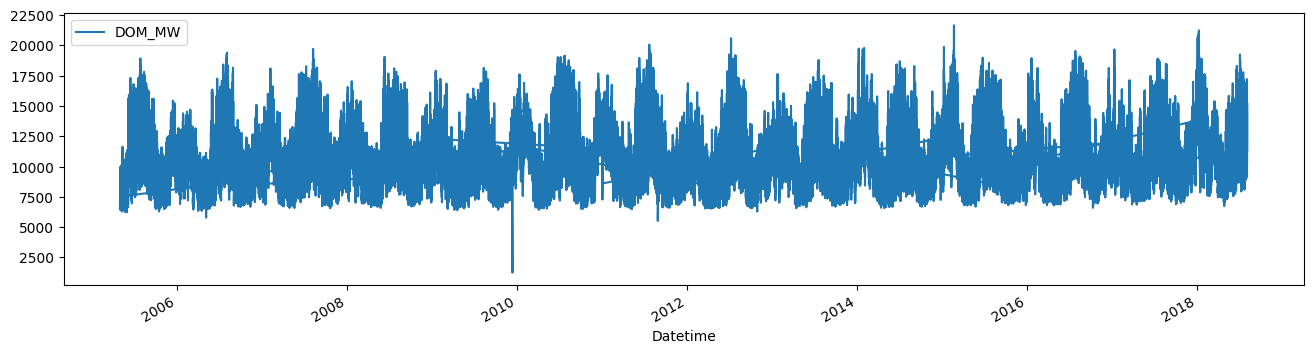

In [ ]:
df.plot(figsize=(16,4),legend=True)
plt.show()

In [ ]:
def normalize_data(df):
    min_max_scaler = sklearn.preprocessing.MinMaxScaler()
    df['DOM_MW']= min_max_scaler.fit_transform(df.DOM_MW.values.reshape(-1,1))
    return df

df_norm = normalize_data(df)
df_norm.shape

(116189, 1)

In [ ]:
def load_data(stock, seq_len):
  X_train=[]
  y_train=[]
  for i in range(seq_len, len(stock)):
    X_train.append(stock.iloc[i-seq_len:i,0])
    y_train.append(stock.iloc[i])

  #print(X_train.shape)
  X_test = X_train[110000:]
  y_test = y_train[110000:]

  X_train = X_train[:110000]
  y_train = y_train[:110000]

  X_test = np.array(X_test)
  y_test = np.array(y_test)

  X_train = np.array(X_train)
  y_train = np.array(y_train)

  X_train = np.reshape(X_train, (110000, seq_len, 1))
  X_test = np.reshape(X_test, (X_test.shape[0], seq_len, 1))

  return [X_train, y_train, X_test, y_test]

In [ ]:
seq_len = 20
X_train, y_train, X_test, y_test = load_data(df_norm, seq_len)

print(X_train.shape)
print(y_train.shape)

(110000, 20, 1)
(110000, 1)


In [ ]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(units=40,activation='tanh' ,return_sequences=True, input_shape=(seq_len,1)))
rnn_model.add(Dropout(0.15))

rnn_model.add(SimpleRNN(units=40, activation='tanh',return_sequences=True))
rnn_model.add(Dropout(0.15))

rnn_model.add(SimpleRNN(units=40, activation='tanh',return_sequences=False))
rnn_model.add(Dropout(0.15))

rnn_model.add(Dense(1))

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 20, 40)         │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 20, 40)         │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,201 (32.04 KB)

 Trainable params: 8,201 (32.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.compile(optimizer = 'adam',loss='MSE')
rnn_model.fit(X_train, y_train, epochs = 10, batch_size = 1000)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - loss: 0.2868
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0422
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0194
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - loss: 0.0122
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - loss: 0.0089
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0070
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0058
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0050
Epoch 9/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0044
Epoch 10/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - loss: 0.0039


In [ ]:
rnn_predictions = rnn_model.predict(X_test)
print(rnn_predictions.shape)

193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
(6169, 1)


In [ ]:
y_test.shape

(6169, 1)

In [ ]:
rnn_score = r2_score(y_test,rnn_predictions)

In [ ]:
rnn_score

0.9300262095781517

In [ ]:
LSTM_model = Sequential()
LSTM_model.add(LSTM(units=40,activation='tanh' ,return_sequences=True, input_shape=(seq_len,1)))
LSTM_model.add(Dropout(0.15))

LSTM_model.add(LSTM(units=40, activation='tanh',return_sequences=True))
LSTM_model.add(Dropout(0.15))

LSTM_model.add(LSTM(units=40, activation='tanh',return_sequences=False))
LSTM_model.add(Dropout(0.15))

LSTM_model.add(Dense(1))

LSTM_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 20, 40)         │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 20, 40)         │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 20, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 40)             │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,681 (127.66 KB)

 Trainable params: 32,681 (127.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
LSTM_model.compile(optimizer = 'adam',loss='MSE')
LSTM_model.fit(X_train, y_train, epochs = 10, batch_size = 1000)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 29s 213ms/step - loss: 0.0513
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 219ms/step - loss: 0.0120
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 40s 207ms/step - loss: 0.0107
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - loss: 0.0065
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 218ms/step - loss: 0.0047
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 218ms/step - loss: 0.0037
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 217ms/step - loss: 0.0030
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 217ms/step - loss: 0.0024
Epoch 9/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - loss: 0.0021
Epoch 10/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 24s 218ms/step - loss: 0.0019


In [ ]:
LSTM_predictions = LSTM_model.predict(X_test)
print(rnn_predictions.shape)

193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
(6169, 1)


In [ ]:
LSTM_predictions = LSTM_model.predict(X_test)
print(LSTM_predictions.shape)


193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
(6169, 1)


In [ ]:
LSTM_score = r2_score(y_test,LSTM_predictions)
print(LSTM_score)
print(LSTM_score)

0.9491247729660056
0.9491247729660056


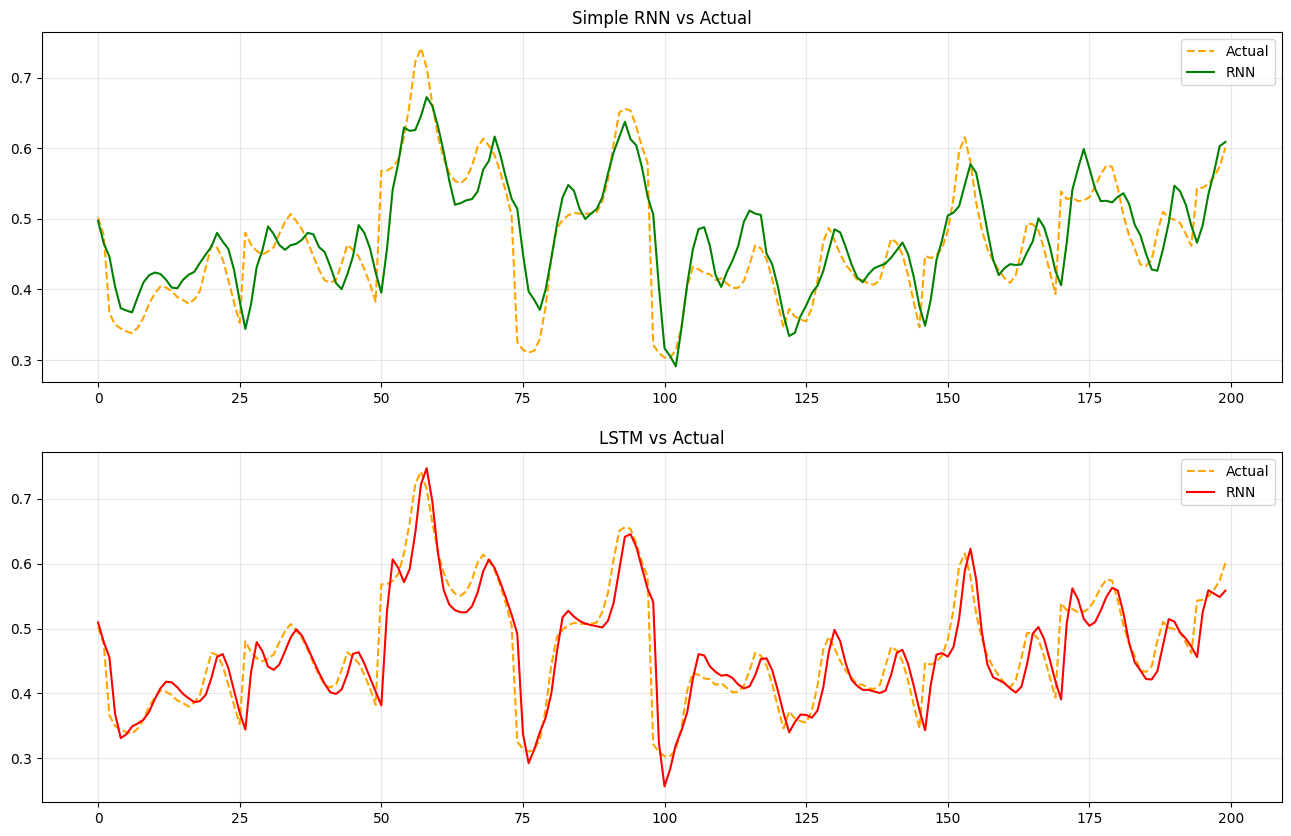

In [ ]:
from matplotlib import lines
start, end = 0,200

plt.figure(figsize = (16,10))

plt.subplot(2,1,1)
plt.plot(y_test[start:end], color = 'orange',linestyle = '--',label = 'Actual')
plt.plot(rnn_predictions[start:end],color = "green",label = 'RNN')
plt.title("Simple RNN vs Actual")
plt.legend()
plt.grid(True, alpha = 0.3)



plt.subplot(2,1,2)
plt.plot(y_test[start:end], color = 'orange',linestyle = '--',label = 'Actual')
plt.plot(LSTM_predictions[start:end],color = "red",label = 'RNN')
plt.title("LSTM vs Actual")
plt.legend()
plt.grid(True, alpha = 0.3)